In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_parquet("../data/processed/spy_processed.parquet")
aggregate = pd.read_parquet("../data/processed/spy_aggregate.parquet")

In [3]:
df['tex'] = -df['theta'] * df['open_interest'] * 100
net_tex = (
    df.groupby("timestamp")["tex"]
    .sum()
    .rename("net_tex")
    .reset_index()
)
aggregate = aggregate.merge(net_tex, on="timestamp", how="left")


In [8]:
aggregate['net_tex_norm'] = aggregate['net_tex'] / aggregate['underlying_price']

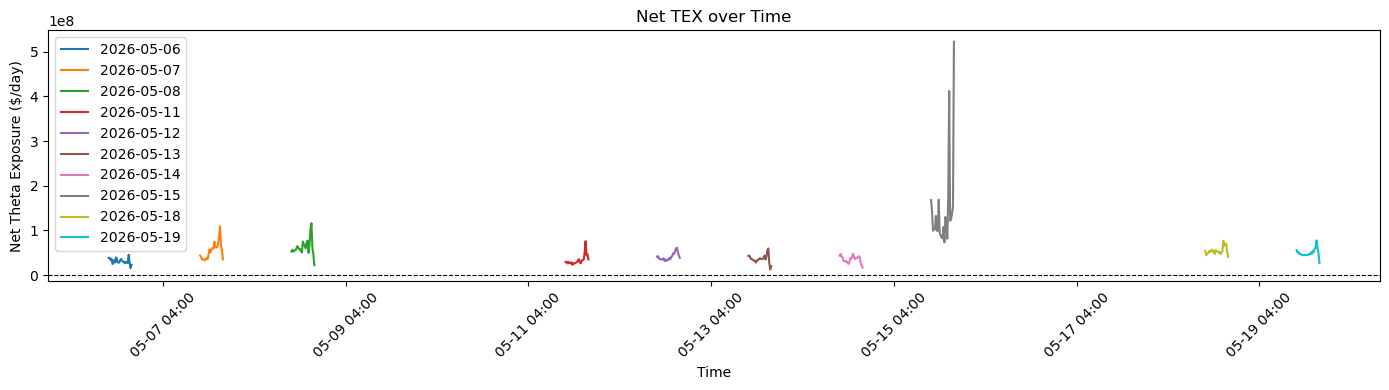

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
for date, group in aggregate.groupby(aggregate["timestamp"].dt.date):
    ax.plot(group["timestamp"], group["net_tex"], label=str(date))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("Net Theta Exposure ($/day)")
ax.set_title("Net TEX over Time")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m-%d %H:%M"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
ttm = (
    df.groupby("timestamp")["ttm_min"]
    .first()
    .rename("ttm_min")
    .reset_index()
)
aggregate = aggregate.merge(ttm, on="timestamp", how="left")
aggregate["ttm_hours"] = aggregate["ttm_min"] / 60
aggregate["theta_decay"] = aggregate["net_tex"] / aggregate["ttm_hours"]
aggregate


,timestamp,net_dex,net_gex,underlying_price,net_gex_norm,net_dex_norm,atm_iv,iv_call_25d,iv_put_25d,iv_skew_25d,iv_smile_curvature_25d,net_tex,net_tex_norm,ttm_min,ttm_hours,theta_decay
0,2026-05-06 09:45:00-04:00,-6.482183e+09,3.514162e+09,729.15,4.819533e+06,-8890054.53,0.16965,0.1586,0.1875,0.0289,0.0068,38437385.59,52715.333731,375.0,6.25,6.149982e+06
1,2026-05-06 10:00:00-04:00,-6.673169e+09,3.507746e+09,729.66,4.807371e+06,-9145586.46,0.16185,0.1538,0.1928,0.0390,0.0229,38582248.09,52877.022298,360.0,6.00,6.430375e+06
2,2026-05-06 10:15:00-04:00,-6.249268e+09,3.465909e+09,730.08,4.747301e+06,-8559702.83,0.16135,0.1469,0.1840,0.0371,0.0082,33915346.32,46454.287640,345.0,5.75,5.898321e+06
3,2026-05-06 10:30:00-04:00,-7.254773e+09,3.651162e+09,730.03,5.001387e+06,-9937636.19,0.16025,0.1489,0.1826,0.0337,0.0110,36641606.53,50191.918866,330.0,5.50,6.662110e+06
4,2026-05-06 10:45:00-04:00,-6.235425e+09,2.971337e+09,731.85,4.060035e+06,-8520086.28,0.14300,0.1347,0.1696,0.0349,0.0183,24772932.90,33849.740931,315.0,5.25,4.718654e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2026-05-19 14:45:00-04:00,1.357632e+09,-1.324910e+09,735.84,-1.800541e+06,1845010.04,0.23725,0.2309,0.2597,0.0288,0.0161,61185100.16,83150.005653,75.0,1.25,4.894808e+07
246,2026-05-19 15:00:00-04:00,1.671626e+09,-1.950403e+09,734.42,-2.655705e+06,2276117.74,0.27925,0.2778,0.2871,0.0093,0.0064,77988586.60,106190.717301,60.0,1.00,7.798859e+07
247,2026-05-19 15:15:00-04:00,1.285933e+09,-1.285623e+09,736.02,-1.746722e+06,1747143.67,0.22770,0.2236,0.2329,0.0093,0.0011,58894969.13,80018.164085,45.0,0.75,7.852663e+07
248,2026-05-19 15:30:00-04:00,2.363966e+09,-2.252909e+09,734.77,-3.066142e+06,3217287.20,0.20060,0.1972,0.2060,0.0088,0.0020,48982817.59,66664.150129,30.0,0.50,9.796564e+07


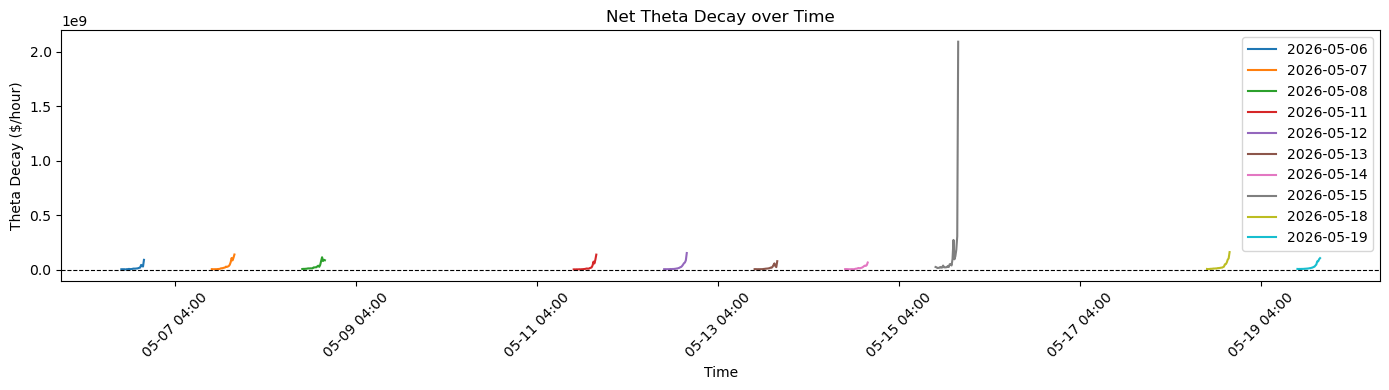

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
for date, group in aggregate.groupby(aggregate["timestamp"].dt.date):
    ax.plot(group["timestamp"], group["theta_decay"], label=str(date))
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Time")
ax.set_ylabel("Theta Decay ($/hour)")
ax.set_title("Net Theta Decay over Time")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%m-%d %H:%M"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
a = aggregate
b = pd.read_parquet("../data/processed/spy_aggregate.parquet")

print(f"Shape:  notebook={a.shape}  script={b.shape}")

only_a = set(a.columns) - set(b.columns)
only_b = set(b.columns) - set(a.columns)
print(f"Only in notebook: {only_a}")
print(f"Only in script:   {only_b}")

sort_keys = ["timestamp"]
common = [c for c in a.columns if c in b.columns]
a_s = a[common].sort_values(sort_keys).reset_index(drop=True)
b_s = b[common].sort_values(sort_keys).reset_index(drop=True)

for col in common:
    if pd.api.types.is_numeric_dtype(a_s[col]):
        if not np.allclose(a_s[col].fillna(0), b_s[col].fillna(0), rtol=1e-5, atol=1e-8):
            diff = (a_s[col] - b_s[col]).abs()
            print(f"MISMATCH {col}: max_diff={diff.max():.6g}, mean_diff={diff.mean():.6g}")
    else:
        mismatches = (a_s[col] != b_s[col]).sum()
        if mismatches:
            print(f"MISMATCH {col}: {mismatches} rows differ")

print("Done")

Shape:  notebook=(250, 16)  script=(250, 16)
Only in notebook: set()
Only in script:   set()
Done
